In [1]:
# Verbindung zu Google Drive aufbauen
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


✅ 5 Szenen gefunden:
  - LC08_L2SP_194025_20250701_20250711_02_T1
  - LC08_L2SP_194025_20250818_20250821_02_T1
  - LC08_L2SP_194025_20250919_20250929_02_T1
  - LC09_L2SP_194025_20250810_20250811_02_T1
  - LC09_L2SP_194025_20250826_20250902_02_T1
✅ 11 Gebiete geladen

🔄 LC08_L2SP_194025_20250701_20250711_02_T1
  ✔ Klare Pixel: 148,895 / 171,500 (86.8%)
  ✔ Albedo | Min: 0.009  Mean: 0.172  Max: 0.582
  ✔ Gespeichert: LC08_L2SP_194025_20250701_20250711_02_T1_Albedo.tif

🔄 LC08_L2SP_194025_20250818_20250821_02_T1
  ✔ Klare Pixel: 171,500 / 171,500 (100.0%)
  ✔ Albedo | Min: 0.002  Mean: 0.152  Max: 0.498
  ✔ Gespeichert: LC08_L2SP_194025_20250818_20250821_02_T1_Albedo.tif

🔄 LC08_L2SP_194025_20250919_20250929_02_T1
  ✔ Klare Pixel: 171,497 / 171,500 (100.0%)
  ✔ Albedo | Min: 0.003  Mean: 0.135  Max: 0.613
  ✔ Gespeichert: LC08_L2SP_194025_20250919_20250929_02_T1_Albedo.tif

🔄 LC09_L2SP_194025_20250810_20250811_02_T1
  ✔ Klare Pixel: 171,500 / 171,500 (100.0%)
  ✔ Albedo | Min: 0.005  Mea

/tmp/ipykernel_4293/2302233688.py:213: RuntimeWarning: Mean of empty slice
  albedo_mean = np.nanmean(albedo_stack, axis=0)


✔ Albedo_MEAN gespeichert | dtype: float32 | nodata: -9999.0
✔ Albedo_MEAN gespeichert
  Mean: 0.151
  Min:  0.005
  Max:  0.513

Gebiet                       Mean     Min     Max     Std      n
  Rottenbauer-Nord          0.143    0.110    0.246  ±0.017     468
  Rottenbauer-Süd           0.142    0.108    0.193  ±0.016     481
  Lengfeld                  0.152    0.119    0.232  ±0.018     178
  Lengfeld-Kern             0.133    0.084    0.176  ±0.016     242
  Hubland Grünfläche        0.165    0.126    0.205  ±0.017     229
  Hubland Terrassen         0.148    0.094    0.181  ±0.021      59
  Hubland Quartier I        0.125    0.096    0.147  ±0.011      70
  Hubland Quartier II       0.133    0.100    0.163  ±0.015      32
  Hubland Quartier III      0.140    0.103    0.238  ±0.023     157
  ─────────────────────────────────────────────────────────────────
  Hubland-Gesamt            0.149    0.094    0.238  ±0.024     545
  Gartenstadt               0.140    0.100    0.196  ±0.0

/tmp/ipykernel_4293/2302233688.py:299: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom       = gdf_reproj.geometry.unary_union
/tmp/ipykernel_4293/2302233688.py:311: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  centroid   = hub_reproj.geometry.unary_union.centroid


✅ Grafik gespeichert: Albedo_Auswertung.png


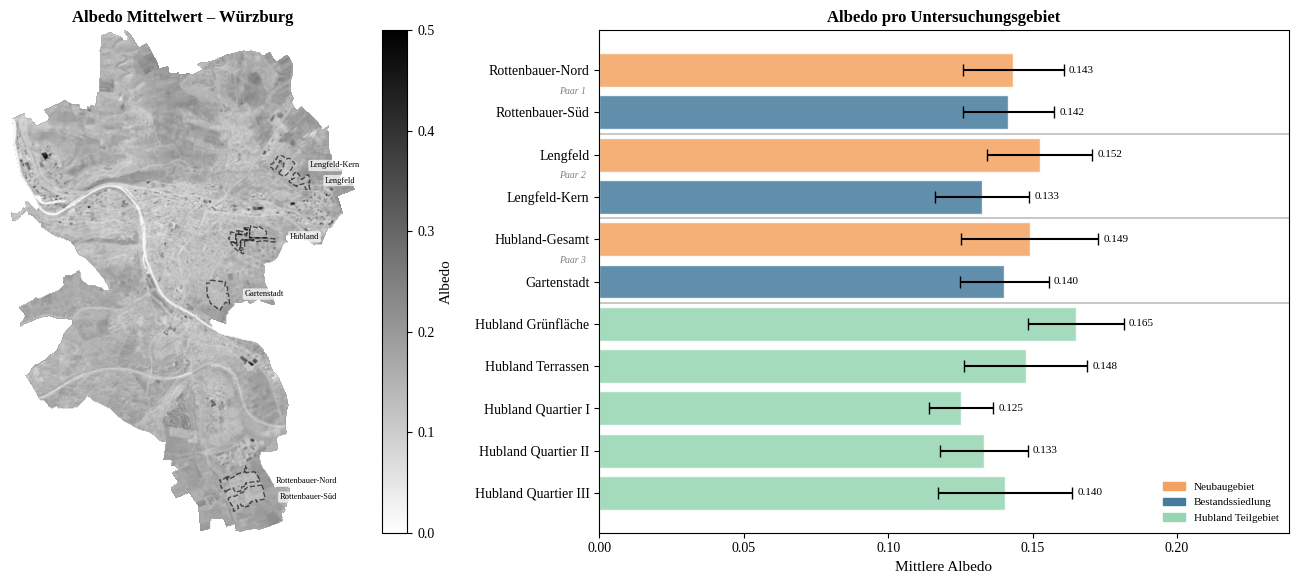

In [2]:

# NOTEBOOK 4 – ALBEDO
#  Aufgabe: Albedo berechnen, Mittelwert bilden, Gebiete auswerten
#  Input:   Landsat/Clipped/ (B2, B4, B5, B6, B7, CLEAR_MASK)
#  Output:  Albedo/Szenen/ + Albedo/Albedo_MEAN.tif + Grafiken/

import rasterio
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib as mpl
import os
from rasterio.mask import mask as rio_mask
from rasterio.transform import rowcol


# SETUP
base        = "/content/drive/MyDrive/Colab_Notebooks"
clip_path   = f"{base}/Landsat/Clipped"
out_path    = f"{base}/Albedo"
szenen_path = f"{base}/Albedo/Szenen"

os.makedirs(szenen_path,        exist_ok=True)
os.makedirs(f"{base}/Grafiken", exist_ok=True)

NODATA     = -9999.0
ALBEDO_MIN =  0.0
ALBEDO_MAX =  1.0
REFL_MIN   =  0.0   # Reflektanz Einzelbänder
REFL_MAX   =  1.0

# ── Farben ────────────────────────────────────────────────────────────────────
FARBE_NEUBAU  = "#f4a261"
FARBE_BESTAND = "#457b9d"
FARBE_TEILGEB = "#95d5b2"

# ── APA 7 Plotstil ────────────────────────────────────────────────────────────
mpl.rcParams["font.family"]      = "serif"
mpl.rcParams["font.serif"]       = ["Liberation Serif", "DejaVu Serif", "Georgia"]
mpl.rcParams["font.size"]        = 12
mpl.rcParams["axes.titlesize"]   = 12
mpl.rcParams["axes.labelsize"]   = 11
mpl.rcParams["xtick.labelsize"]  = 10
mpl.rcParams["ytick.labelsize"]  = 10
mpl.rcParams["legend.fontsize"]  = 10
mpl.rcParams["axes.facecolor"]   = "white"
mpl.rcParams["figure.facecolor"] = "white"
mpl.rcParams["axes.grid"]        = False
mpl.rcParams["savefig.dpi"]      = 300
mpl.rcParams["savefig.bbox"]     = "tight"
mpl.rcParams["legend.frameon"]   = False

# ── Szenen-IDs aus Clipped-Ordner ableiten ────────────────────────────────────
scene_ids = sorted(set(
    f.replace("_CLEAR_MASK.tif", "")
    for f in os.listdir(clip_path)
    if f.endswith("_CLEAR_MASK.tif")
))
print(f"✅ {len(scene_ids)} Szenen gefunden:")
for s in scene_ids:
    print(f"  - {s}")

# ── Gebiete laden ─────────────────────────────────────────────────────────────
shapefile_pfade = {
    "Rottenbauer-Nord":     f"{base}/Shapefiles_Gebiete/Rottenbauer/Shape_Rottenbauer_Nord.shp",
    "Rottenbauer-Süd":      f"{base}/Shapefiles_Gebiete/Rottenbauer/Shape_Rottenbauer_alt.shp",
    "Lengfeld":             f"{base}/Shapefiles_Gebiete/Lengfeld/Shape_Lengfeld.shp",
    "Lengfeld-Kern":        f"{base}/Shapefiles_Gebiete/Lengfeld/Shape_Lengfeld_alt.shp",
    "Hubland Grünfläche":   f"{base}/Shapefiles_Gebiete/Hubland/Shape_Hubland_Gruenflaeche.shp",
    "Hubland Terrassen":    f"{base}/Shapefiles_Gebiete/Hubland/Shape_Hublandterrassen.shp",
    "Hubland Quartier I":   f"{base}/Shapefiles_Gebiete/Hubland/Shape_Quartier_I.shp",
    "Hubland Quartier II":  f"{base}/Shapefiles_Gebiete/Hubland/Shape_Quartier_II_plus_BBP_70.shp",
    "Hubland Quartier III": f"{base}/Shapefiles_Gebiete/Hubland/Shape_Quartier_III.shp",
    "Hubland-Gesamt":       f"{base}/Shapefiles_Gebiete/Hubland/Shape_Hubland_Gesamt.shp",
    "Gartenstadt":          f"{base}/Shapefiles_Gebiete/Gartenstadt/Shape_Gartenstadt.shp",
}

gebiete_gdfs   = {name: gpd.read_file(pfad)
                  for name, pfad in shapefile_pfade.items()}
gebiete_final  = gebiete_gdfs
hubland_gesamt = gebiete_gdfs["Hubland-Gesamt"]

print(f"✅ {len(gebiete_final)} Gebiete geladen")


# SCHRITT 1: Hilfsfunktion – Band laden, skalieren & maskieren

def lade_band(path, clear_mask):
    """
    Lädt ein SR-Band, wendet Scale Factor an und maskiert
    Wolken sowie unplausible Reflexionswerte.

    Scale Factor Landsat Collection 2:
    Reflektanz = DN × 0.0000275 + (−0.2)
    """
    with rasterio.open(path) as src:
        arr = src.read(1).astype(np.float32)
        nd  = src.nodata

    # NoData & Nullwerte maskieren
    if nd is not None:
        arr[arr == nd] = np.nan
    arr[arr == 0] = np.nan

    # Scale Factor anwenden → physikalische Reflexionswerte
    arr = np.where(~np.isnan(arr), arr * 0.0000275 + (-0.2), np.nan)

    # Wolkenpixel ausschließen
    arr = np.where(clear_mask == 1, arr, np.nan)

    # Plausibilitätsfilter Reflexion [0, 1]
    arr = np.where(
        (arr >= REFL_MIN) & (arr <= REFL_MAX),
        arr, np.nan
    )

    return arr

# SCHRITT 2: Albedo pro Szene berechnen

albedo_stack = []
meta_ref     = None

for scene_id in scene_ids:
    print(f"\n{'='*60}")
    print(f"🔄 {scene_id}")

    b2_path   = os.path.join(clip_path, f"{scene_id}_SR_B2_clip.tif")
    b4_path   = os.path.join(clip_path, f"{scene_id}_SR_B4_clip.tif")
    b5_path   = os.path.join(clip_path, f"{scene_id}_SR_B5_clip.tif")
    b6_path   = os.path.join(clip_path, f"{scene_id}_SR_B6_clip.tif")
    b7_path   = os.path.join(clip_path, f"{scene_id}_SR_B7_clip.tif")
    mask_path = os.path.join(clip_path, f"{scene_id}_CLEAR_MASK.tif")

    # ── Dateien prüfen ────────────────────────────────────────────────────────
    alle_pfade = {
        "B2": b2_path, "B4": b4_path, "B5": b5_path,
        "B6": b6_path, "B7": b7_path, "MASK": mask_path
    }
    fehlend = [name for name, p in alle_pfade.items()
               if not os.path.exists(p)]
    if fehlend:
        print(f"  ⚠️ Fehlende Dateien: {fehlend} – Szene übersprungen!")
        continue

    # ── Wolkenmaske laden (aus Notebook 1) ────────────────────────────────────
    with rasterio.open(mask_path) as src:
        clear_mask = src.read(1)

    pct = clear_mask.sum() / clear_mask.size * 100
    print(f"  ✔ Klare Pixel: {clear_mask.sum():,} / "
          f"{clear_mask.size:,} ({pct:.1f}%)")

    # ── Bänder laden & skalieren ──────────────────────────────────────────────
    with rasterio.open(b2_path) as src:
        meta = src.meta.copy()

    b2 = lade_band(b2_path, clear_mask)
    b4 = lade_band(b4_path, clear_mask)
    b5 = lade_band(b5_path, clear_mask)
    b6 = lade_band(b6_path, clear_mask)
    b7 = lade_band(b7_path, clear_mask)

    if meta_ref is None:
        meta_ref = meta.copy()

    # ── Albedo berechnen nach Dong et al. (2022) ──────────────────────────────
    # α = 0.356×ρ(B2) + 0.130×ρ(B4) + 0.373×ρ(B5)
    #   + 0.085×ρ(B6) + 0.072×ρ(B7) − 0.0018
    albedo = (
        0.356 * b2 +
        0.130 * b4 +
        0.373 * b5 +
        0.085 * b6 +
        0.072 * b7 -
        0.0018
    )

    # ── Plausibilitätsfilter Albedo [0, 1] ───────────────────────────────────
    albedo = np.where(
        (albedo >= ALBEDO_MIN) & (albedo <= ALBEDO_MAX),
        albedo, np.nan
    )

    valid = albedo[~np.isnan(albedo)]
    if len(valid) == 0:
        print("  ⚠️ Keine gültigen Pixel – Szene übersprungen!")
        continue

    print(f"  ✔ Albedo | Min: {np.nanmin(valid):.3f}  "
          f"Mean: {np.nanmean(valid):.3f}  Max: {np.nanmax(valid):.3f}")

    # ── Pro Szene speichern ───────────────────────────────────────────────────
    out_meta = meta_ref.copy()
    out_meta.update(dtype=rasterio.float32, count=1, nodata=NODATA)
    szene_out = os.path.join(szenen_path, f"{scene_id}_Albedo.tif")
    arr_out   = np.where(np.isnan(albedo), NODATA, albedo)
    meta_ref_mean = meta_ref.copy()
    meta_ref_mean.update(dtype=rasterio.float32, count=1, nodata=NODATA)
    with rasterio.open(szene_out, "w", **out_meta) as dst:
        dst.write(arr_out.astype(np.float32), 1)
    print(f"  ✔ Gespeichert: {scene_id}_Albedo.tif")

    albedo_stack.append(albedo)


# SCHRITT 3: Pixelweiser Mittelwert über alle Szenen

albedo_stack = np.array(albedo_stack)
print(f"\nShape des Albedo-Stacks: {albedo_stack.shape} "
      f"→ {albedo_stack.shape[0]} Szenen")

albedo_mean = np.nanmean(albedo_stack, axis=0)

albedo_mean_path = os.path.join(out_path, "Albedo_MEAN.tif")
arr_out = np.where(np.isnan(albedo_mean), NODATA, albedo_mean)

mean_meta = {
    "driver":    "GTiff",
    "dtype":     rasterio.float32,
    "count":     1,
    "nodata":    NODATA,
    "height":    albedo_mean.shape[0],
    "width":     albedo_mean.shape[1],
    "transform": meta_ref["transform"],
    "crs":       meta_ref["crs"],
}

with rasterio.open(albedo_mean_path, "w", **mean_meta) as dst:
    dst.write(arr_out.astype(np.float32), 1)
print(f"✔ Albedo_MEAN gespeichert | dtype: float32 | nodata: {NODATA}")
print(f"✔ Albedo_MEAN gespeichert")
print(f"  Mean: {np.nanmean(albedo_mean):.3f}")
print(f"  Min:  {np.nanmin(albedo_mean):.3f}")
print(f"  Max:  {np.nanmax(albedo_mean):.3f}")


# SCHRITT 4: Gebietsauswertung

def albedo_stats(gdf, raster_path, nodata=NODATA):
    """Schneidet Albedo_MEAN auf Gebiet zu und berechnet Statistiken."""
    with rasterio.open(raster_path) as src:
        gdf_reproj = gdf.to_crs(src.crs)
        geoms      = list(gdf_reproj.geometry)
        clipped, _ = rio_mask(src, geoms, crop=True, nodata=nodata)
    arr = clipped[0].astype(np.float32)
    arr[arr == nodata]   = np.nan
    arr[arr < ALBEDO_MIN] = np.nan
    arr[arr > ALBEDO_MAX] = np.nan
    valid = arr[~np.isnan(arr)]
    if len(valid) == 0:
        return {"mean": np.nan, "min": np.nan,
                "max": np.nan, "std": np.nan, "n": 0}
    return {
        "mean": np.nanmean(valid),
        "min":  np.nanmin(valid),
        "max":  np.nanmax(valid),
        "std":  np.nanstd(valid),
        "n":    len(valid),
    }

print("\n" + "=" * 65)
print(f"{'Gebiet':<25} {'Mean':>7} {'Min':>7} {'Max':>7} "
      f"{'Std':>7} {'n':>6}")
print("=" * 65)

ergebnisse_albedo = {}
for name, gdf in gebiete_final.items():
    s = albedo_stats(gdf, albedo_mean_path)
    ergebnisse_albedo[name] = s
    trennlinie = "─" * 65 if name == "Hubland-Gesamt" else ""
    if trennlinie:
        print(f"  {trennlinie}")
    print(f"  {name:<23} {s['mean']:>7.3f}  {s['min']:>7.3f}  "
          f"{s['max']:>7.3f}  ±{s['std']:>5.3f}  {s['n']:>6}")


# SCHRITT 5: Visualisierung Übersicht

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Plot 1: Albedo Karte ──────────────────────────────────────────────────────
ax = axes[0]
arr_plot = np.where(albedo_mean == NODATA, np.nan, albedo_mean)
im = ax.imshow(arr_plot, cmap="gray_r", vmin=0, vmax=0.5)
plt.colorbar(im, ax=ax, label="Albedo", fraction=0.046, pad=0.04)
ax.set_title("Albedo Mittelwert – Würzburg", fontweight="bold")
ax.axis("off")

with rasterio.open(albedo_mean_path) as src:
    raster_transform = src.transform
    raster_crs       = src.crs

beschriftet = set()
for name, gdf in gebiete_final.items():
    if name == "Hubland-Gesamt":
        continue
    gdf_reproj = gdf.to_crs(raster_crs)
    geom       = gdf_reproj.geometry.unary_union
    if hasattr(geom, "exterior"):
        xs, ys = geom.exterior.coords.xy
    else:
        xs, ys = geom.convex_hull.exterior.coords.xy
    rows, cols = rowcol(raster_transform, xs, ys)
    ax.plot(cols, rows, color="black", linewidth=1.0,
            linestyle="--", alpha=0.6)
    anzeige_name = "Hubland" if "Hubland" in name else name
    if anzeige_name not in beschriftet:
        if "Hubland" in name:
            hub_reproj = hubland_gesamt.to_crs(raster_crs)
            centroid   = hub_reproj.geometry.unary_union.centroid
        else:
            centroid = geom.centroid
        cr, cc = rowcol(raster_transform, centroid.x, centroid.y)
        ax.annotate(
            anzeige_name,
            xy=(max(cols), cr), xytext=(max(cols) + 15, cr),
            fontsize=6, ha="left", va="center", color="black",
            annotation_clip=False,
            bbox=dict(boxstyle="round,pad=0.2",
                      fc="white", alpha=0.7, ec="none")
        )
        beschriftet.add(anzeige_name)

# ── Plot 2: Balkendiagramm mit Matched Pairs ──────────────────────────────────
ax = axes[1]

reihenfolge = [
    "Rottenbauer-Nord", "Rottenbauer-Süd",
    "Lengfeld",         "Lengfeld-Kern",
    "Hubland-Gesamt",   "Gartenstadt",
    "Hubland Grünfläche", "Hubland Terrassen",
    "Hubland Quartier I", "Hubland Quartier II", "Hubland Quartier III",
]

farben_dict = {
    "Rottenbauer-Nord":     FARBE_NEUBAU,
    "Rottenbauer-Süd":      FARBE_BESTAND,
    "Lengfeld":             FARBE_NEUBAU,
    "Lengfeld-Kern":        FARBE_BESTAND,
    "Hubland-Gesamt":       FARBE_NEUBAU,
    "Gartenstadt":          FARBE_BESTAND,
    "Hubland Grünfläche":   FARBE_TEILGEB,
    "Hubland Terrassen":    FARBE_TEILGEB,
    "Hubland Quartier I":   FARBE_TEILGEB,
    "Hubland Quartier II":  FARBE_TEILGEB,
    "Hubland Quartier III": FARBE_TEILGEB,
}

means  = [ergebnisse_albedo[n]["mean"] for n in reihenfolge]
stds   = [ergebnisse_albedo[n]["std"]  for n in reihenfolge]
farben = [farben_dict[n]                for n in reihenfolge]

bars = ax.barh(reihenfolge, means, xerr=stds,
               color=farben, alpha=0.85,
               edgecolor="white", capsize=4)
ax.bar_label(bars, fmt="%.3f", padding=4, fontsize=8)

for y in [1.5, 3.5, 5.5]:
    ax.axhline(y=y, color="gray", linewidth=1.2,
               linestyle="-", alpha=0.5)

for y_pos, label in {0.5: "Paar 1",
                     2.5: "Paar 2",
                     4.5: "Paar 3"}.items():
    ax.text(-0.02, y_pos, label,
            transform=ax.get_yaxis_transform(),
            ha="right", va="center",
            fontsize=7, color="gray", style="italic")

ax.legend(handles=[
    mpatches.Patch(color=FARBE_NEUBAU,  label="Neubaugebiet"),
    mpatches.Patch(color=FARBE_BESTAND, label="Bestandssiedlung"),
    mpatches.Patch(color=FARBE_TEILGEB, label="Hubland Teilgebiet"),
], fontsize=8, loc="lower right")

ax.set_xlim(0, max(means) + max(stds) + 0.05)
ax.set_xlabel("Mittlere Albedo")
ax.set_title("Albedo pro Untersuchungsgebiet", fontweight="bold")
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(
    f"{base}/Grafiken/Albedo_Auswertung.png",
    dpi=300, bbox_inches="tight", facecolor="white"
)
print("✅ Grafik gespeichert: Albedo_Auswertung.png")
plt.show()

Farbskala:
vmin = 0.108
vmax = 0.191


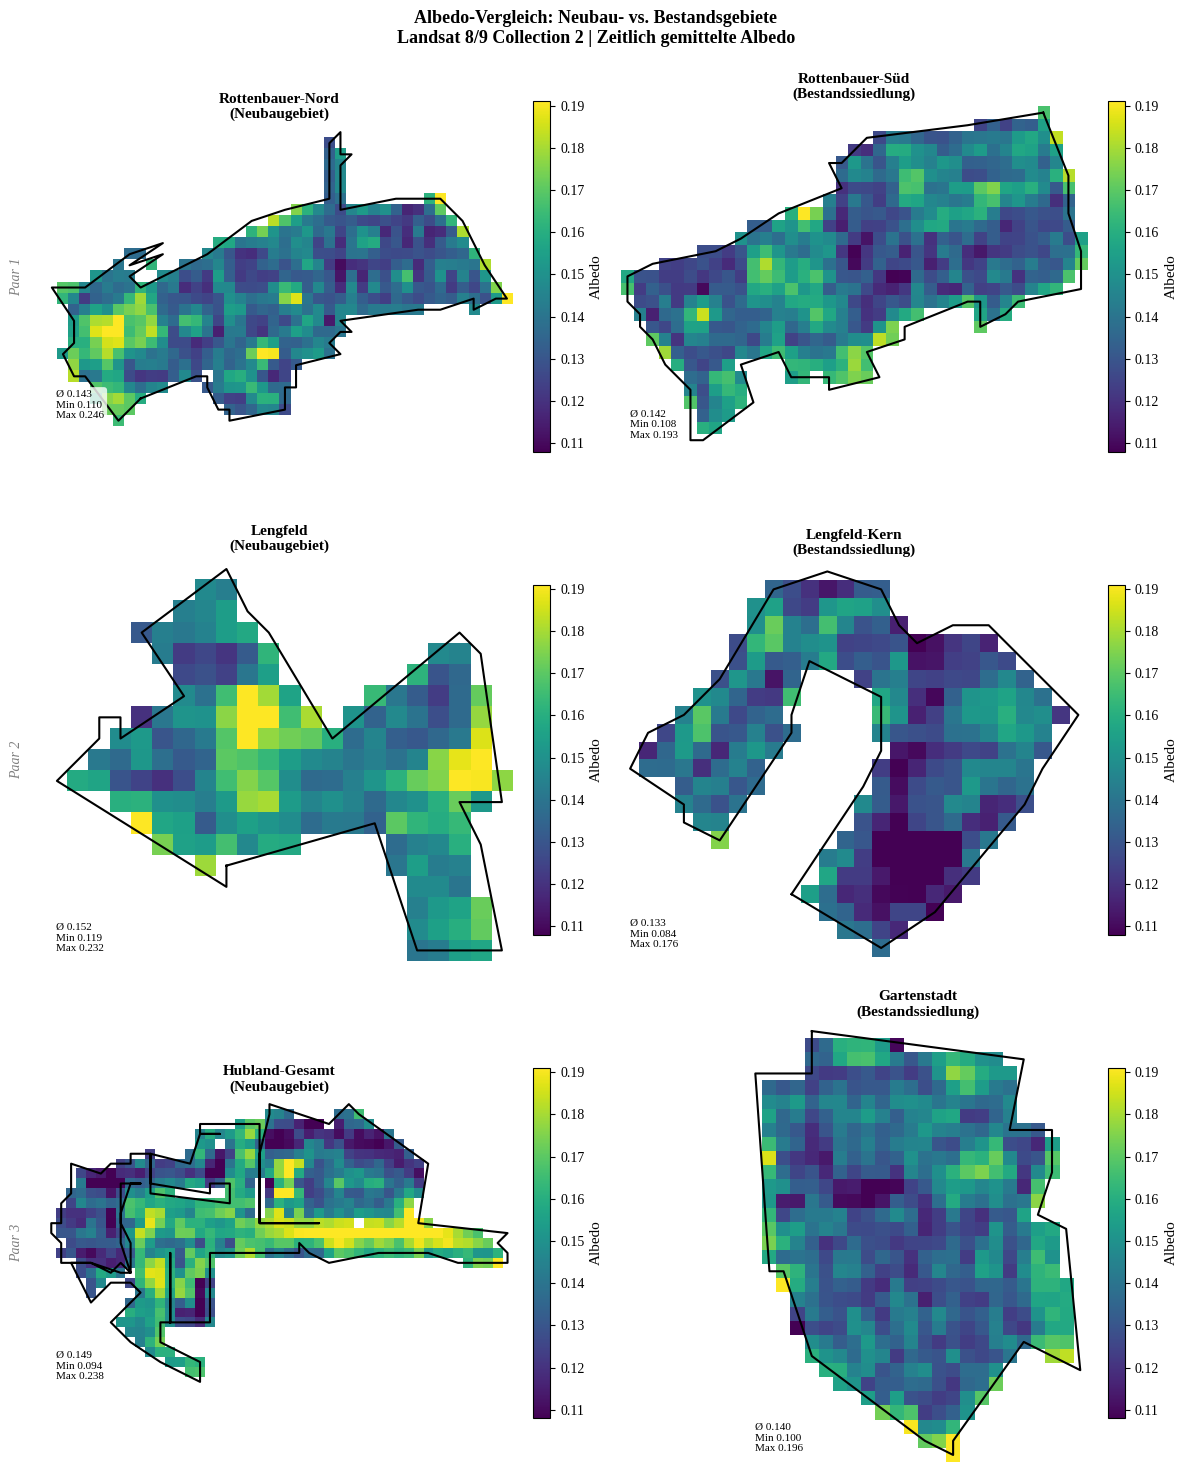

✅ Grafik gespeichert unter:
/content/drive/MyDrive/Colab_Notebooks/Grafiken/Albedo_Paarvergleich_Karten.png


In [3]:
# ── Paarweise Albedo-Karten der Untersuchungsgebiete ──────────────────────────
from rasterio.mask import mask as rio_mask

paare = [
    ("Rottenbauer-Nord", "Rottenbauer-Süd"),
    ("Lengfeld",         "Lengfeld-Kern"),
    ("Hubland-Gesamt",   "Gartenstadt"),
]

with rasterio.open(albedo_mean_path) as src:
    raster_crs = src.crs
# ── Gemeinsame Farbskala aus allen Untersuchungsgebieten ───────────────────

alle_werte = []

with rasterio.open(albedo_mean_path) as src:
    raster_crs = src.crs
    for name, gdf in gebiete_final.items():
        gdf = gdf.to_crs(raster_crs)
        clipped, _ = rio_mask(
            src,
            list(gdf.geometry),
            crop=True,
            nodata=NODATA
        )
        arr = clipped[0].astype(np.float32)
        arr[arr == NODATA] = np.nan
        valid = arr[~np.isnan(arr)]
        if len(valid) > 0:
            alle_werte.extend(valid)
alle_werte = np.array(alle_werte)
vmin = np.nanpercentile(alle_werte, 2)
vmax = np.nanpercentile(alle_werte, 98)
print(f"Farbskala:")
print(f"vmin = {vmin:.3f}")
print(f"vmax = {vmax:.3f}")
fig, axes = plt.subplots(len(paare), 2, figsize=(12, len(paare) * 5))
for row, (neubau, bestand) in enumerate(paare):
    for col, name in enumerate([neubau, bestand]):
        ax = axes[row, col]
        gdf = gebiete_final[name].to_crs(raster_crs)
        with rasterio.open(albedo_mean_path) as src:
            clipped, clip_transform = rio_mask(
                src,
                list(gdf.geometry),
                crop=True,
                nodata=NODATA
            )

        arr = clipped[0].astype(np.float32)
        arr[arr == NODATA] = np.nan

        # Karte
        im = ax.imshow(
            arr,
            cmap="viridis",
            vmin=vmin,
            vmax=vmax
        )

        # Gebietsgrenze
        from rasterio.transform import rowcol as rc
        geom = gdf.geometry.union_all()
        if hasattr(geom, "exterior"):
            xs, ys = geom.exterior.coords.xy
        else:
            xs, ys = geom.convex_hull.exterior.coords.xy
        rows, cols = rc(clip_transform, xs, ys)
        ax.plot(
            cols,
            rows,
            color="black",
            linewidth=1.5
        )

        # Titel
        gruppe = (
            "Neubaugebiet"
            if col == 0
            else "Bestandssiedlung"
        )
        ax.set_title(
            f"{name}\n({gruppe})",
            fontsize=11,
            fontweight="bold"
        )
        ax.axis("off")

        # Colorbar
        plt.colorbar(
            im,
            ax=ax,
            label="Albedo",
            fraction=0.046,
            pad=0.04,
            shrink=0.8
        )

        # Statistikbox
        valid = arr[~np.isnan(arr)]
        if len(valid) > 0:
            stats_text = (
                f"Ø {np.nanmean(valid):.3f}\n"
                f"Min {np.nanmin(valid):.3f}\n"
                f"Max {np.nanmax(valid):.3f}"
            )

            ax.text(
                0.02,
                0.02,
                stats_text,
                transform=ax.transAxes,
                fontsize=8,
                va="bottom",
                ha="left",
                bbox=dict(
                    boxstyle="round,pad=0.3",
                    fc="white",
                    alpha=0.8,
                    ec="none"
                )
            )

    # Paar-Label links
    axes[row, 0].text(
        -0.05,
        0.5,
        f"Paar {row+1}",
        transform=axes[row, 0].transAxes,
        fontsize=10,
        color="gray",
        style="italic",
        va="center",
        ha="right",
        rotation=90
    )

fig.suptitle(
    "Albedo-Vergleich: Neubau- vs. Bestandsgebiete\n"
    "Landsat 8/9 Collection 2 | Zeitlich gemittelte Albedo",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    f"{base}/Grafiken/Albedo_Paarvergleich_Karten.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print(
    "✅ Grafik gespeichert unter:\n"
    f"{base}/Grafiken/Albedo_Paarvergleich_Karten.png"
)

Gebiet                      Ø Albedo     Gruppe
  Rottenbauer-Nord           0.1433   Neubau
  Rottenbauer-Süd            0.1416   Bestand
  ─────────────────────────────────────────────
  Lengfeld                   0.1524   Neubau
  Lengfeld-Kern              0.1325   Bestand
  ─────────────────────────────────────────────
  Hubland-Gesamt             0.1490   Neubau
  Gartenstadt                0.1401   Bestand
  ─────────────────────────────────────────────

  Mittelwert Neubau          0.1482
  Mittelwert Bestand         0.1381

── Differenzen pro Paar (Neubau − Bestand) ──
  Rottenbauer               +0.0016   ↑ Neubau höher
  Lengfeld                  +0.0199   ↑ Neubau höher
  Hubland//Gartenstadt      +0.0089   ↑ Neubau höher

── Wilcoxon-Vorzeichen-Rang-Test (zweiseitig) ──
   Teststatistik W: 0.000
   p-Wert:          0.250
   n Paare:         3
   → Nicht signifikant (p ≥ 0.10) ❌
      Hinweis: Bei n=3 Paaren ist die statistische
      Power sehr begrenzt – deskriptive Unter

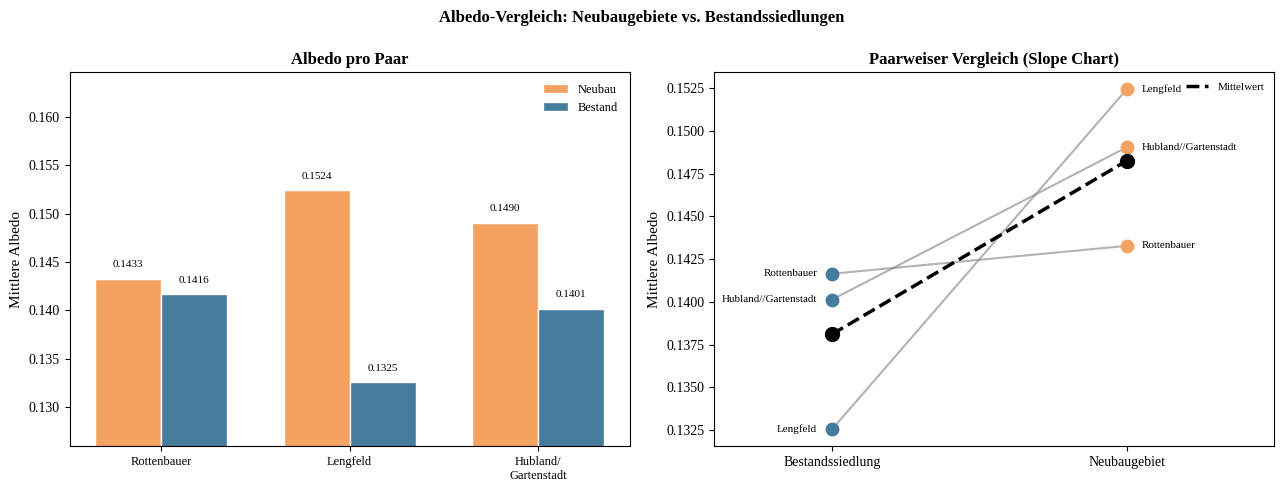

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# SCHRITT 6: Statistische Analyse – Wilcoxon Paarvergleich Albedo
# ═══════════════════════════════════════════════════════════════════════════════

from scipy import stats

# ── Paare definieren ──────────────────────────────────────────────────────────
paare = [
    ("Rottenbauer-Nord", "Rottenbauer-Süd"),
    ("Lengfeld",         "Lengfeld-Kern"),
    ("Hubland-Gesamt",   "Gartenstadt"),
]
paar_labels = ["Rottenbauer", "Lengfeld", "Hubland/\nGartenstadt"]

# ── Funktion: mittlere Albedo pro Gebiet ──────────────────────────────────────
def albedo_mean_gebiet(gdf):
    with rasterio.open(albedo_mean_path) as src:
        gdf_reproj = gdf.to_crs(src.crs)
        geoms      = list(gdf_reproj.geometry)
        clipped, _ = rio_mask(src, geoms, crop=True, nodata=np.nan)
    arr = clipped[0].astype(np.float32)
    arr[arr <= ALBEDO_MIN] = np.nan
    arr[arr >  ALBEDO_MAX] = np.nan
    return float(np.nanmean(arr))

# ── Mittelwerte berechnen ─────────────────────────────────────────────────────
neubau_albedo  = []
bestand_albedo = []

print("=" * 55)
print(f"{'Gebiet':<25} {'Ø Albedo':>10} {'Gruppe':>10}")
print("=" * 55)

for neubau, bestand in paare:
    mean_neubau  = albedo_mean_gebiet(gebiete_final[neubau])
    mean_bestand = albedo_mean_gebiet(gebiete_final[bestand])
    neubau_albedo.append(mean_neubau)
    bestand_albedo.append(mean_bestand)
    print(f"  {neubau:<23} {mean_neubau:>9.4f}   Neubau")
    print(f"  {bestand:<23} {mean_bestand:>9.4f}   Bestand")
    print(f"  {'─' * 45}")

print(f"\n  {'Mittelwert Neubau':<23} {np.mean(neubau_albedo):>9.4f}")
print(f"  {'Mittelwert Bestand':<23} {np.mean(bestand_albedo):>9.4f}")
print("=" * 55)

# ── Differenzen pro Paar ──────────────────────────────────────────────────────
diff_paare = [n - b for n, b in zip(neubau_albedo, bestand_albedo)]

print("\n── Differenzen pro Paar (Neubau − Bestand) ──")
for label, d in zip(paar_labels, diff_paare):
    richtung = "↑ Neubau höher" if d > 0 else "↓ Bestand höher"
    print(f"  {label.replace(chr(10), '/'):<25} {d:>+.4f}   {richtung}")

# ── Wilcoxon-Vorzeichen-Rang-Test ─────────────────────────────────────────────
stat, p = stats.wilcoxon(neubau_albedo, bestand_albedo, alternative='two-sided')

print(f"\n── Wilcoxon-Vorzeichen-Rang-Test (zweiseitig) ──")
print(f"   Teststatistik W: {stat:.3f}")
print(f"   p-Wert:          {p:.3f}")
print(f"   n Paare:         {len(paare)}")

if p < 0.05:
    print("   → Signifikant (p < 0.05) ✅")
elif p < 0.10:
    print("   → Tendenz erkennbar (p < 0.10) ⚠️")
else:
    print("   → Nicht signifikant (p ≥ 0.10) ❌")
    print("      Hinweis: Bei n=3 Paaren ist die statistische")
    print("      Power sehr begrenzt – deskriptive Unterschiede")
    print("      bleiben dennoch inhaltlich interpretierbar!")

# ── Visualisierung Paarvergleich ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1: Gruppiertes Balkendiagramm
ax1 = axes[0]
x      = np.arange(len(paare))
breite = 0.35

balken_neubau  = ax1.bar(x - breite/2, neubau_albedo,  breite,
                          label="Neubau",  color=FARBE_NEUBAU,
                          edgecolor="white")
balken_bestand = ax1.bar(x + breite/2, bestand_albedo, breite,
                          label="Bestand", color=FARBE_BESTAND,
                          edgecolor="white")

for bar in balken_neubau:
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.001,
             f"{bar.get_height():.4f}",
             ha="center", va="bottom", fontsize=8)
for bar in balken_bestand:
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.001,
             f"{bar.get_height():.4f}",
             ha="center", va="bottom", fontsize=8)

ax1.set_xticks(x)
ax1.set_xticklabels(paar_labels, fontsize=9)
ax1.set_ylabel("Mittlere Albedo")
ax1.set_title("Albedo pro Paar", fontweight="bold")
ax1.legend(fontsize=9)
ax1.set_ylim(min(neubau_albedo + bestand_albedo) * 0.95,
             max(neubau_albedo + bestand_albedo) * 1.08)

# Plot 2: Slope Chart
ax2 = axes[1]

for label, n, b in zip(paar_labels, neubau_albedo, bestand_albedo):
    ax2.plot([0, 1], [b, n], color="gray",
             linewidth=1.5, alpha=0.6, zorder=1)
    ax2.scatter(0, b, color=FARBE_BESTAND, s=80, zorder=2)
    ax2.scatter(1, n, color=FARBE_NEUBAU,  s=80, zorder=2)
    ax2.text(1.05, n, label.replace("\n", "/"),
             va="center", fontsize=8)
    ax2.text(-0.05, b, label.replace("\n", "/"),
             va="center", ha="right", fontsize=8)

ax2.plot([0, 1],
         [np.mean(bestand_albedo), np.mean(neubau_albedo)],
         color="black", linewidth=2.5, linestyle="--",
         zorder=3, label="Mittelwert")
ax2.scatter([0, 1],
            [np.mean(bestand_albedo), np.mean(neubau_albedo)],
            color="black", s=100, zorder=4)

ax2.set_xticks([0, 1])
ax2.set_xticklabels(["Bestandssiedlung", "Neubaugebiet"], fontsize=10)
ax2.set_xlim(-0.4, 1.5)
ax2.set_ylabel("Mittlere Albedo")
ax2.set_title("Paarweiser Vergleich (Slope Chart)", fontweight="bold")
ax2.legend(fontsize=8)

plt.suptitle(
    "Albedo-Vergleich: Neubaugebiete vs. Bestandssiedlungen",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.savefig(
    f"{base}/Grafiken/Albedo_Paarvergleich.png",
    dpi=300, bbox_inches="tight", facecolor="white"
)
print("✅ Grafik gespeichert: Albedo_Paarvergleich.png")
plt.show()